In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

In [18]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [19]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [22]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)


In [23]:
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]


In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.8626024913276569
ROC AUC: 0.8222430432885948
              precision    recall  f1-score   support

         0.0       0.89      0.97      0.92     43667
         1.0       0.52      0.23      0.32      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.60      0.62     50736
weighted avg       0.83      0.86      0.84     50736



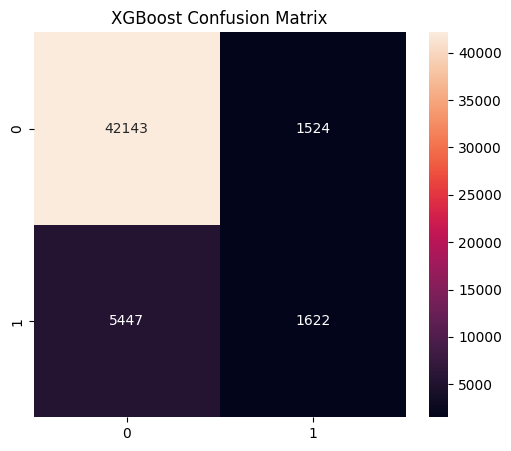

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

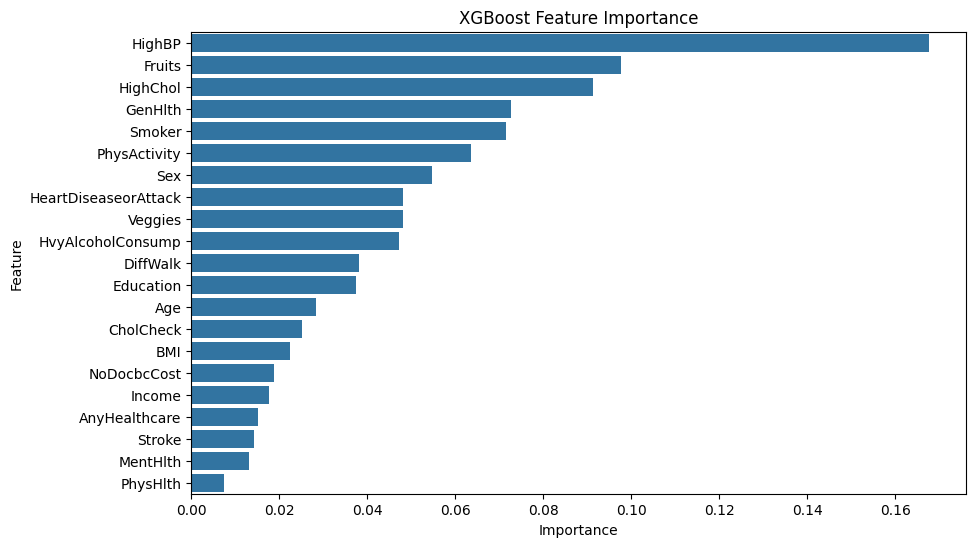

In [27]:

importance = xgb.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_df,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.show()

In [28]:
!pip install shap lime

```markdown
### 1. SHAP (Global and Local Explanations)
SHAP values attribute the prediction of an instance to its features by calculating the contribution of each feature to the prediction.
```

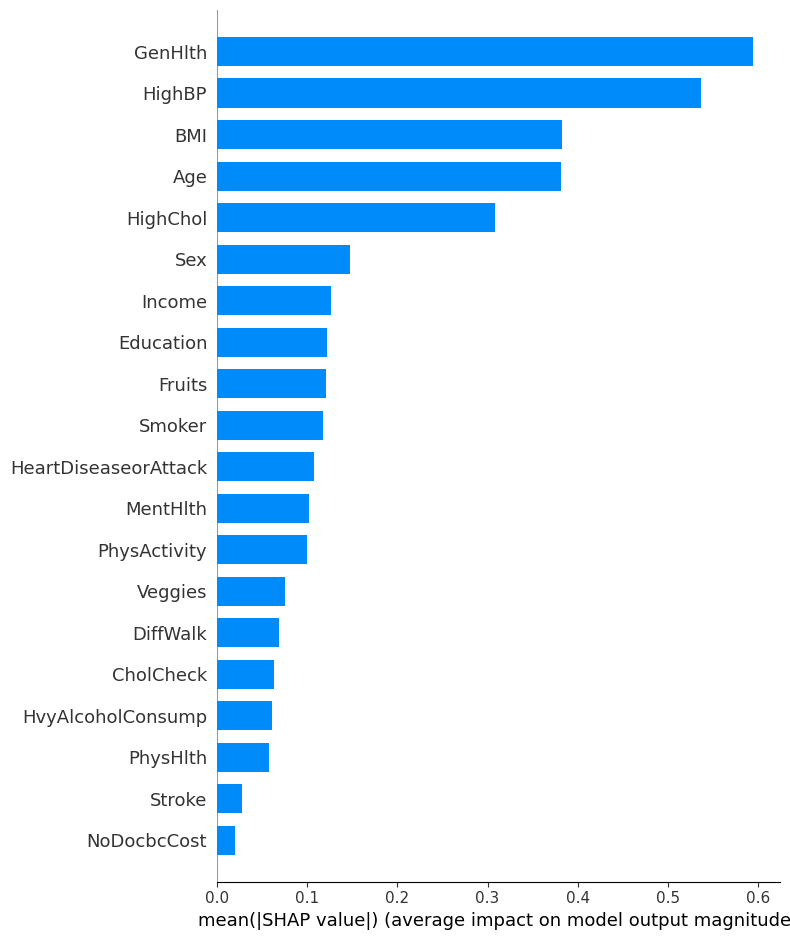

In [29]:
import shap
import matplotlib.pyplot as plt

try:
    # Explainer for Tree-based models
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_test)

    # Summary Plot
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_test, plot_type="bar")
except NameError:
    print("Error: 'xgb' or 'X_test' not found. Please re-run the model training cells.")

```markdown
### 2. LIME (Local Interpretability)
LIME explains a single prediction by training a local surrogate model around that specific instance.
```

In [30]:
from lime import lime_tabular
import numpy as np

try:
    predict_fn = lambda x: xgb.predict_proba(x).astype(float)
    explainer_lime = lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=X.columns.tolist(),
        class_names=['No Diabetes', 'Diabetes'],
        mode='classification'
    )
    i = 0
    exp = explainer_lime.explain_instance(X_test.values[i], predict_fn, num_features=10)
    exp.show_in_notebook(show_table=True)
except NameError as e:
    print(f"Error: {e}. Please ensure X_train and xgb are defined.")

```markdown
### 3. Permutation Importance
Unlike built-in feature importance, this measures the drop in model score when a single feature value is randomly shuffled.
```

/tmp/ipykernel_2029/852766022.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


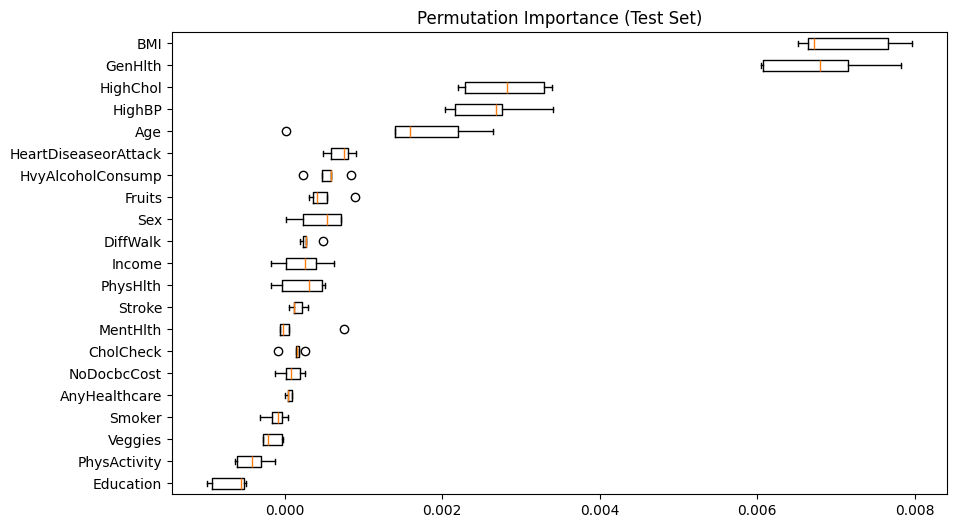

In [31]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

try:
    result = permutation_importance(xgb, X_test, y_test, n_repeats=5, random_state=42)
    sorted_idx = result.importances_mean.argsort()
    plt.figure(figsize=(10,6))
    plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
    plt.title("Permutation Importance (Test Set)")
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please ensure the model and test data are loaded.")

```markdown
### 4. Partial Dependence Plots (PDP)
PDPs show the marginal effect one or two features have on the predicted outcome.
```

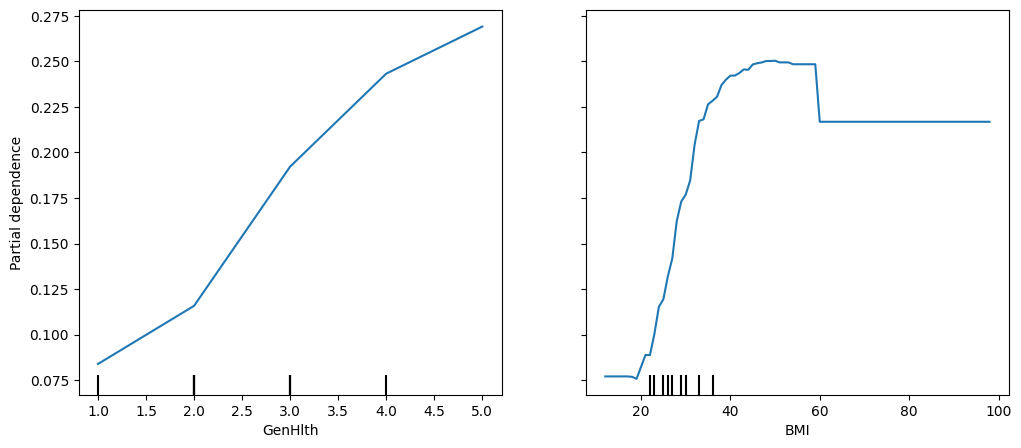

In [32]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

try:
    fig, ax = plt.subplots(figsize=(12, 5))
    PartialDependenceDisplay.from_estimator(xgb, X_test, features=['GenHlth', 'BMI'], ax=ax)
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please ensure plt, xgb, and X_test are defined.")

```markdown
### 5. Precision-Recall Curve
For imbalanced datasets, the PR curve is more informative than the ROC curve as it focuses on the performance of the minority class (Diabetes cases).
```

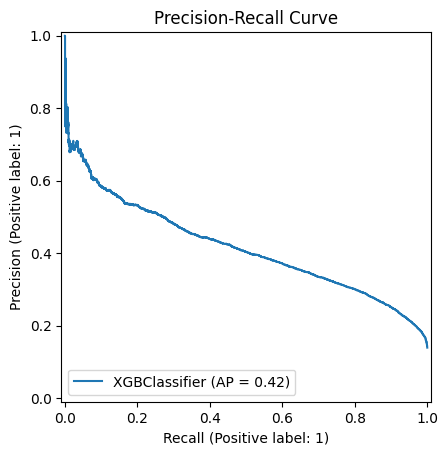

In [33]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

try:
    PrecisionRecallDisplay.from_estimator(xgb, X_test, y_test)
    plt.title("Precision-Recall Curve")
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please ensure the model and data are defined.")